# 3. Фильтрация и выделение границ изображений

## 1. Зачем нужна фильтрация изображений?

* В реальных задачах изображения часто содержат **шум** (помехи).
  Источники шума: низкое освещение, высокая ISO-чувствительность камеры, ошибки передачи данных.
* Перед анализом (например, выделением контуров) полезно **сгладить изображение**, чтобы убрать шум, сохранив при этом важные детали.
* Фильтрация → это преобразование пикселей изображения на основе соседних значений.

---

## 2. Основные типы фильтров

### 2.1. Линейные фильтры (сверточные)

* Основаны на **свертке** изображения с ядром (матрицей весов).
* Каждый новый пиксель вычисляется как взвешенная сумма соседей.
* Примеры:

  * **Box filter (усредняющий):**
    Берет среднее значение соседних пикселей. Хорошо подавляет шум, но размывает границы.
  * **Gaussian filter (гауссовский):**
    Использует ядро, где центр имеет больший вес, а края — меньший. Лучше сохраняет детали по сравнению с простым усреднением.

### 2.2. Нелинейные фильтры

* Пример: **медианный фильтр**.
* Новый пиксель = медиана значений в окрестности.
* Эффективен против «соляного и перечного» шума (белые и черные точки), при этом сохраняет границы.

---

## 3. Выделение границ на изображении

### 3.1. Что такое граница?

* **Граница** — это место на изображении, где резко меняется яркость.
* В терминах математики: граница соответствует **большим значениям градиента** функции яркости.

### 3.2. Методы выделения границ

1. **Sobel оператор**

   * Использует свертку с двумя ядрами (по X и Y).
   * Даёт направления и силу градиента.
   * Подходит для нахождения вертикальных/горизонтальных контуров.

2. **Laplacian оператор**

   * Основан на второй производной.
   * Хорошо находит резкие перепады, но чувствителен к шуму.
   * Чаще применяется после сглаживания (например, Gaussian).

3. **Canny оператор** (один из самых популярных)

   * Многошаговый алгоритм:

     1. Сглаживание (обычно Gaussian).
     2. Вычисление градиента.
     3. Подавление немаксимальных значений (оставляем только «острые» контуры).
     4. Двойная пороговая фильтрация (отбор сильных и слабых границ).
   * Даёт устойчивый и «чистый» результат.

---

## 4. Влияние фильтрации на выделение границ

* Если применить выделение границ к зашумленному изображению → алгоритмы найдут много «ложных» контуров.
* Поэтому **обычно перед выделением границ применяют фильтрацию** (Gaussian или медианный фильтр).
* Медианный фильтр часто используется перед Canny, так как он хорошо убирает точечный шум.

---

## 5. Метрики оценки качества фильтрации

Чтобы объективно сравнить фильтры, можно использовать метрики:

* **MSE (Mean Squared Error):** среднеквадратичная ошибка между оригиналом и обработанным изображением.
* **PSNR (Peak Signal-to-Noise Ratio):**

  $$
  PSNR = 20 \cdot \log_{10}\left(\frac{MAX}{\sqrt{MSE}}\right)
  $$

  где MAX = 255 для 8-битных изображений.
  Чем выше PSNR, тем меньше искажений.

---

## 6. Выводы

1. Фильтрация — важный этап предобработки изображений.
2. Линейные фильтры сглаживают шум, но могут размывать детали.
3. Медианный фильтр хорошо работает с точечным шумом и сохраняет границы.
4. Для выделения границ лучше использовать Sobel (направление), Laplacian (резкие перепады) или Canny (наиболее устойчивый).
5. Качество фильтрации и выделения границ можно оценивать как визуально, так и по метрикам (например, PSNR).



In [1]:
# Сглаживание изображений
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('example.jpg', cv2.IMREAD_GRAYSCALE)

blur = cv2.blur(img, (5,5))                # усредняющий
gaussian = cv2.GaussianBlur(img, (5,5), 0) # гауссовский
median = cv2.medianBlur(img, 5)            # медианный


In [2]:
def show_images(images, titles, cmap='gray'):
    """Функция для отображения нескольких изображений рядом"""
    n = len(images)
    plt.figure(figsize=(15,5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap=cmap)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

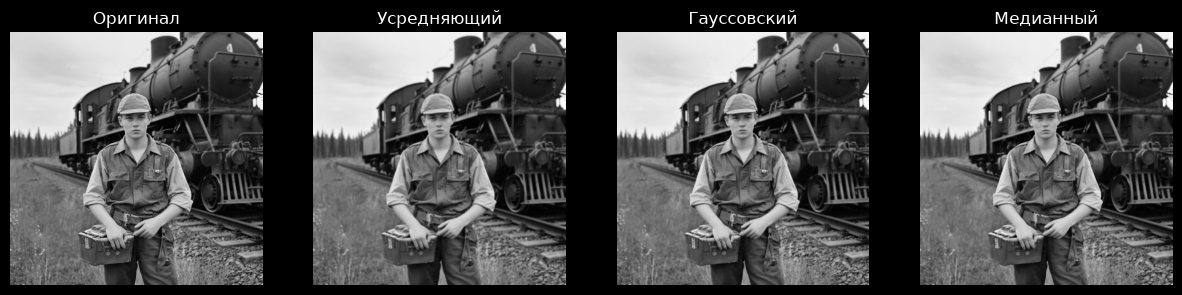

In [3]:
# Сравним результаты визуально

show_images([img, blur, gaussian, median],
            ["Оригинал", "Усредняющий", "Гауссовский", "Медианный"])

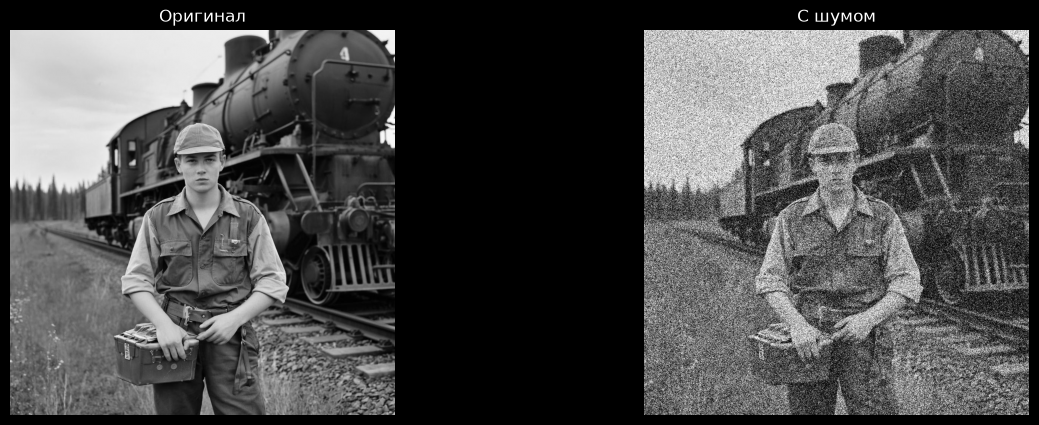

In [4]:
# Добавим шум (для наглядности)

import numpy as np

noise = np.random.normal(0, 100, img.shape).astype(np.int16) # кто пояснит, зачем?
noisy_img = cv2.add(img.astype(np.int16), noise)
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

show_images([img, noisy_img], ["Оригинал", "С шумом"])


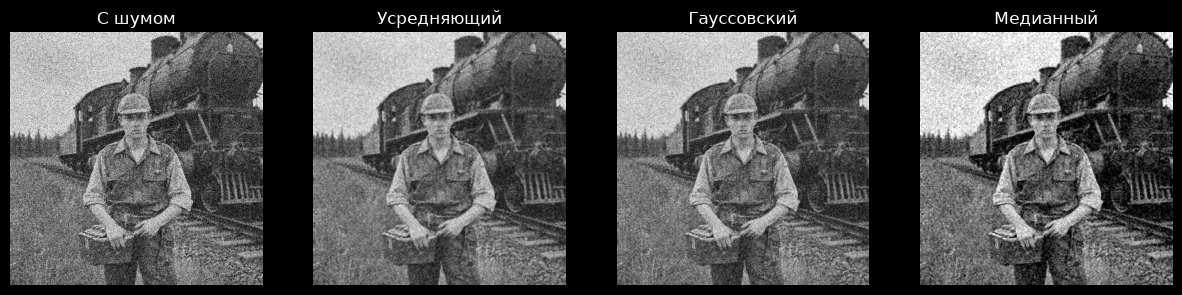

In [5]:
blur = cv2.blur(noisy_img, (5,5))                # усредняющий фильтр
gaussian = cv2.GaussianBlur(noisy_img, (5,5), 0) # гауссовский фильтр
median = cv2.medianBlur(noisy_img, 5)            # медианный фильтр

show_images([noisy_img, blur, gaussian, median],
            ["С шумом", "Усредняющий", "Гауссовский", "Медианный"])

Сравним с использованием метрики

https://ru.wikipedia.org/wiki/%D0%9F%D0%B8%D0%BA%D0%BE%D0%B2%D0%BE%D0%B5_%D0%BE%D1%82%D0%BD%D0%BE%D1%88%D0%B5%D0%BD%D0%B8%D0%B5_%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%B0_%D0%BA_%D1%88%D1%83%D0%BC%D1%83

In [6]:
def psnr(img1, img2):
    """Вычисление PSNR между двумя изображениями"""
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

print("PSNR (шумное → оригинал):", psnr(img, noisy_img))
print("PSNR (усредняющий → оригинал):", psnr(img, blur))
print("PSNR (гауссовский → оригинал):", psnr(img, gaussian))
print("PSNR (медианный → оригинал):", psnr(img, median))

PSNR (шумное → оригинал): 27.89132553069124
PSNR (усредняющий → оригинал): 28.25322395579207
PSNR (гауссовский → оригинал): 28.208711276990858
PSNR (медианный → оригинал): 28.495438126427352


# Зашумленое изображение лучше по метрике, чем отфильтрованное

### 1. **PSNR измеряет только разницу по пикселям**

PSNR = функция от MSE (среднеквадратичной ошибки).
Фильтрация изменяет изображение не только убирая шум, но и сглаживая **полезные детали** (контуры, текстуры).

 Даже если шум убран, размытость добавляет дополнительные отличия от оригинала → MSE растёт → PSNR падает.

---

### 2. **Шум иногда «ближе к истине» в среднем**

* В шумном изображении структура остаётся ближе к оригинальной, только "зашумлена".
* После фильтрации — структура искажается сильнее (например, углы сглаживаются).
* Алгоритм PSNR этого «не понимает», он видит только среднюю разницу в яркости пикселей.

---

### 3. **PSNR ≠ восприятие качества**

Человек оценивает визуально: «фильтрованное» выглядит лучше (меньше шума).
Но PSNR может показать обратное.
Поэтому PSNR считается **плохим показателем для визуального качества** (особенно при шумоподавлении и сжатии).

---

## 🛠 Как можно улучшить оценку

1. Использовать **SSIM (Structural Similarity Index)** — он лучше отражает визуальное восприятие.

   ```python
   from skimage.metrics import structural_similarity as ssim

   ssim_value = ssim(img, median, data_range=255)
   print("SSIM (медианный → оригинал):", ssim_value)
   ```

   * SSIM ближе к 1 = лучше.

2. Для лабораторных можно сравнивать **и PSNR, и SSIM** → студенты увидят разницу между численной и визуальной оценкой.

---

 То есть:

* **PSNR** "ругает" фильтр за то, что он меняет даже правильные пиксели.
* **SSIM** "хвалит" фильтр, если структура (формы, границы) сохранена.



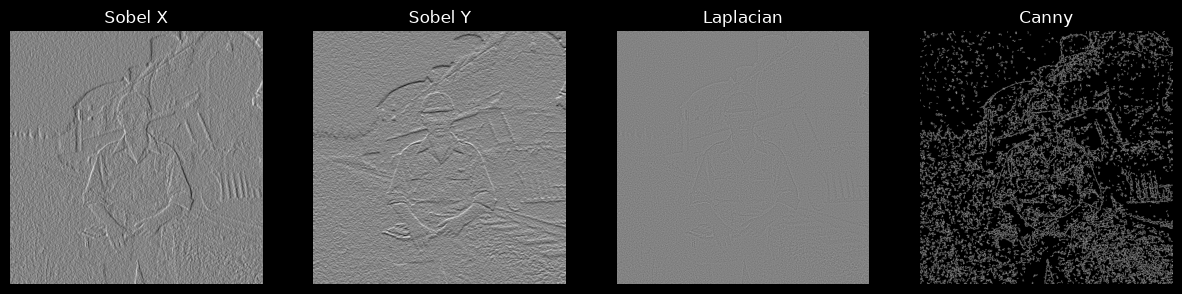

In [7]:
# Выделение границ

sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=5)
laplacian = cv2.Laplacian(blur, cv2.CV_64F)
canny = cv2.Canny(blur, 100, 200)

show_images([
    sobelx, sobely, laplacian, canny
], [
    "Sobel X", "Sobel Y", "Laplacian", "Canny"
])

Sobel даёт направление градиента.
Laplacian реагирует на резкие перепады, но чувствителен к шуму.
Canny → более устойчивый результат.

Мини-задание для студентов

Взять собственное изображение (например, фото с телефона).
Добавить искусственный шум (Gaussian/ Salt & Pepper).
Попробовать разные фильтры → затем выделить границы.
Сделать вывод: какой метод фильтрации лучше подготовил изображение к выделению границ.

---

Доп. задания

1. **Вертикальные изображения.** Переписать `show_images`, чтобы изображения выводились горпизонтально.

1. **Свой шум «соль и перец».** Написать функцию `add_salt_pepper(img, p)`, которая с вероятностью `p` заменяет пиксель на 0 или 255. Проверить на своём фото: какой фильтр справляется лучше всех? Оценить по PSNR.

2. **Подбор порогов Canny.** Прогнать `cv2.Canny` по сетке порогов (например, 30/100, 50/150, 100/200, 150/300), вывести рядом и посчитать количество граничных пикселей для каждого варианта. Сделать вывод: как пороги влияют на «чувствительность» детектора?


## Индивидуальные задания

### Собственное изображение (фото)


In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def to_rgb(im):
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)


img = cv2.imread("image.jpg")
if img is None:
    raise FileNotFoundError("Не удалось прочитать: image.jpg")

scale = 0.25
img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

img_rgb = to_rgb(img)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape[:2]
print(f"Оригинал (уменьшен в {1/scale:.0f} раз): {w}x{h}")



Оригинал (уменьшен в 4 раз): 360x640


### Добавить искусственный шум (Gaussian / Salt & Pepper)

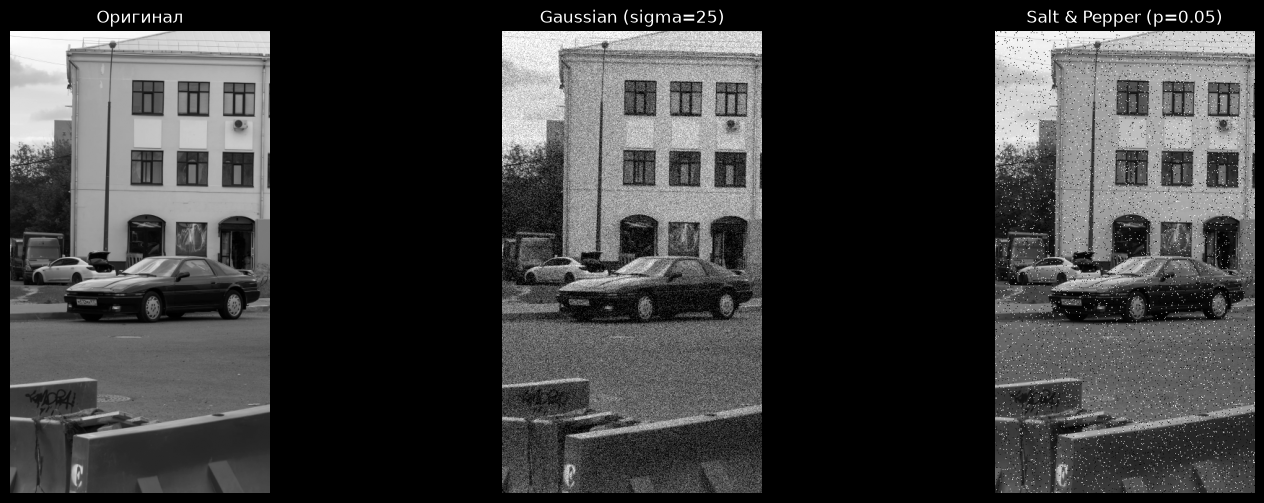

In [9]:
def add_gaussian(img, sigma=25):
    noise = np.random.normal(0, sigma, img.shape)
    return np.clip(img.astype(np.float64) + noise, 0, 255).astype(np.uint8)


def add_salt_pepper(img, p):
    noisy = img.copy()
    rnd = np.random.rand(*img.shape[:2])
    noisy[rnd < p / 2] = 0
    noisy[(rnd >= p / 2) & (rnd < p)] = 255
    return noisy


noisy_gauss = add_gaussian(gray, sigma=25)
noisy_sp = add_salt_pepper(gray, p=0.05)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(gray, cmap="gray")
ax[0].set_title("Оригинал")
ax[1].imshow(noisy_gauss, cmap="gray")
ax[1].set_title("Gaussian (sigma=25)")
ax[2].imshow(noisy_sp, cmap="gray")
ax[2].set_title("Salt & Pepper (p=0.05)")
for a in ax:
    a.axis("off")
plt.show()


### Попробовать разные фильтры

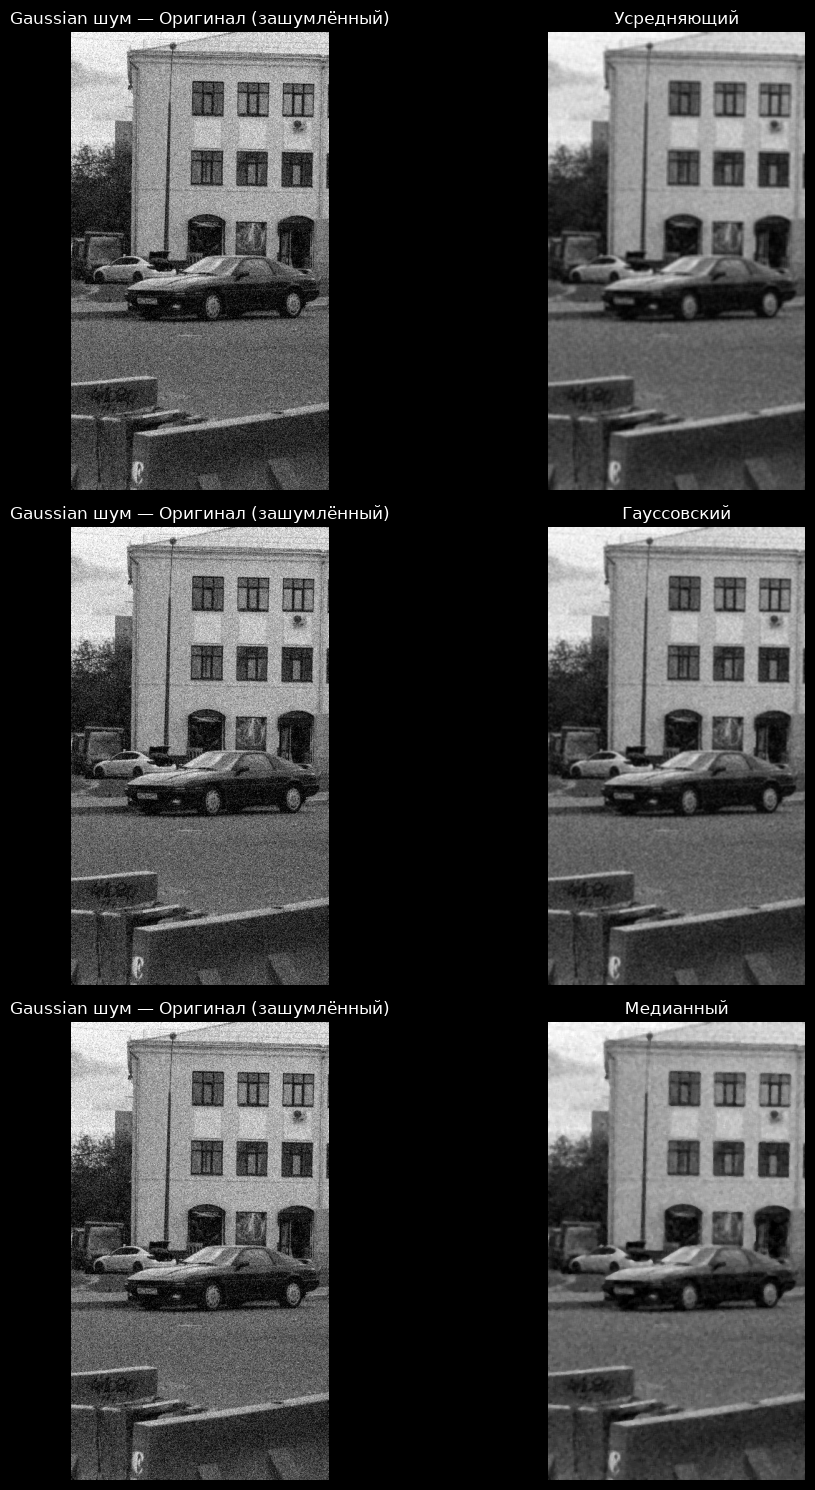

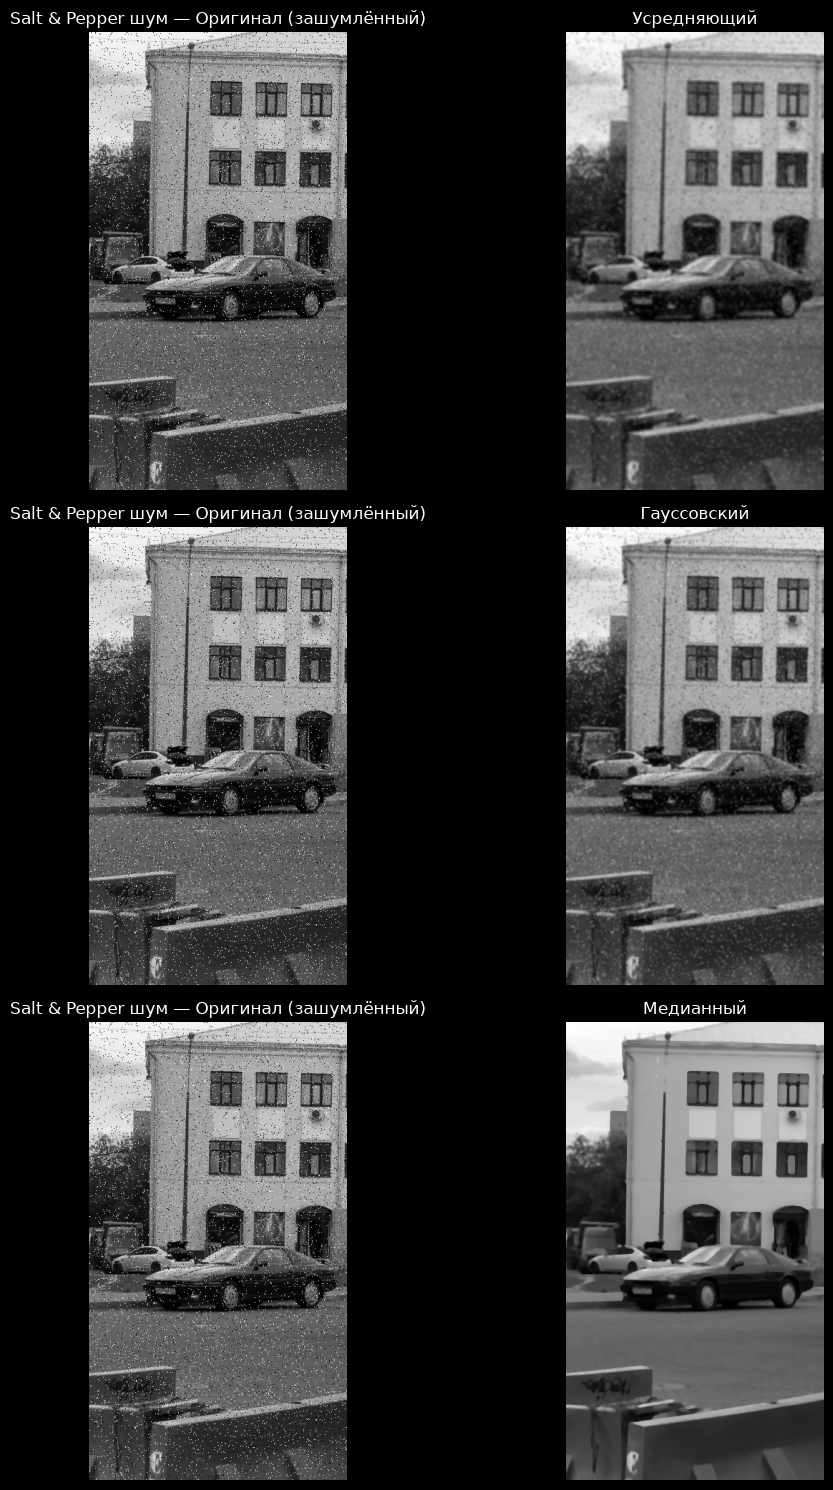

In [10]:
def try_filters(noisy, title):
    blur = cv2.blur(noisy, (5, 5))
    gaus = cv2.GaussianBlur(noisy, (5, 5), 0)
    med = cv2.medianBlur(noisy, 5)

    filters = [
        ("Усредняющий", blur),
        ("Гауссовский", gaus),
        ("Медианный", med),
    ]

    fig, ax = plt.subplots(len(filters), 2, figsize=(12, 5 * len(filters)))
    for row, (name, result) in enumerate(filters):
        ax[row, 0].imshow(noisy, cmap="gray")
        ax[row, 0].set_title(f"{title} — Оригинал (зашумлённый)")
        ax[row, 0].axis("off")
        ax[row, 1].imshow(result, cmap="gray")
        ax[row, 1].set_title(f"{name}")
        ax[row, 1].axis("off")
    plt.tight_layout()
    plt.show()


try_filters(noisy_gauss, "Gaussian шум")
try_filters(noisy_sp, "Salt & Pepper шум")


### Выделение границ

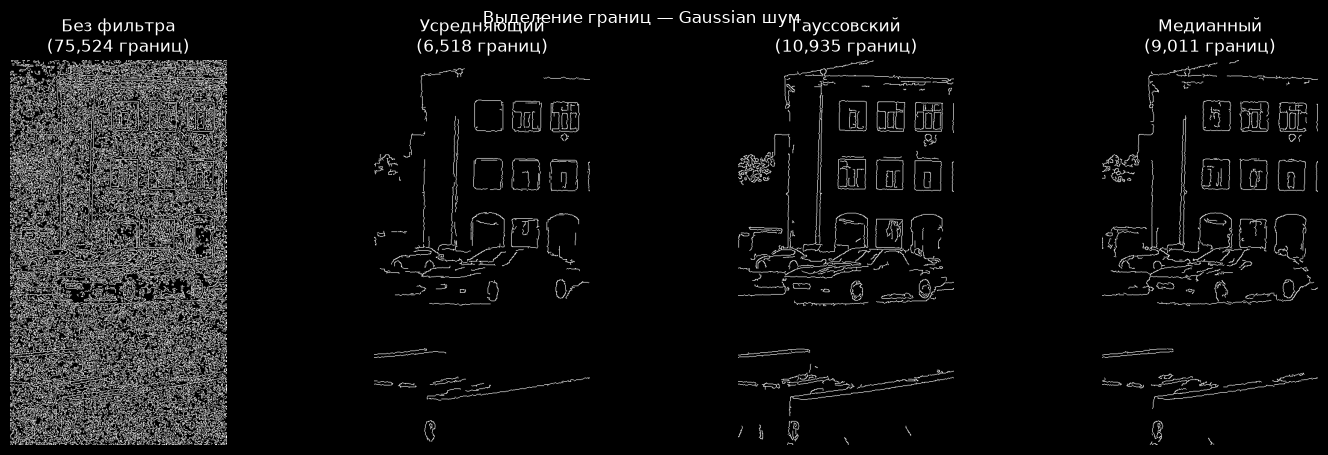

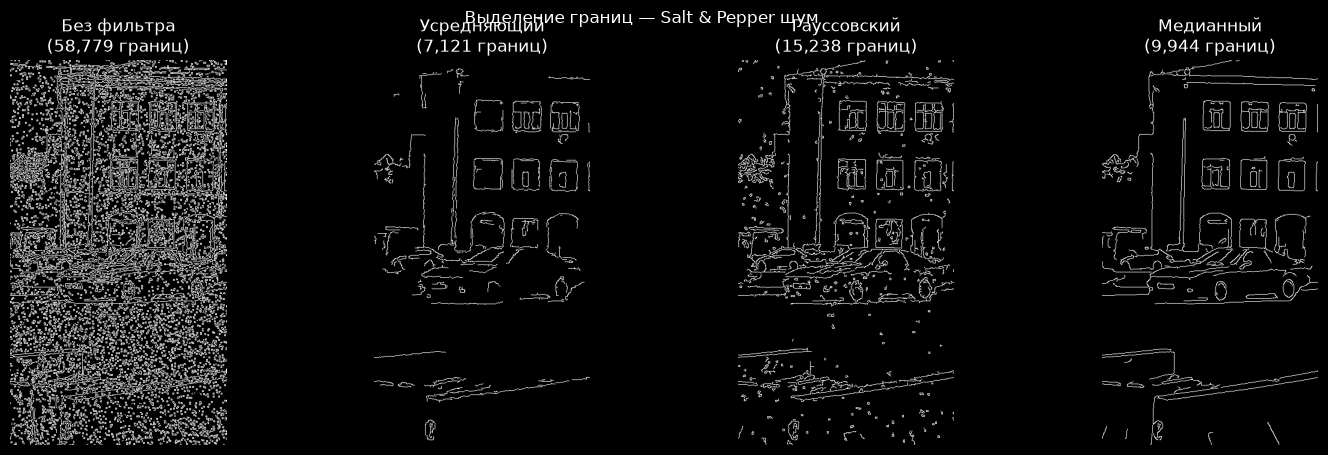

In [11]:
def edges_after_filtering(noisy, title):
    blur = cv2.blur(noisy, (5, 5))
    gaus = cv2.GaussianBlur(noisy, (5, 5), 0)
    med = cv2.medianBlur(noisy, 5)

    fig, ax = plt.subplots(1, 4, figsize=(18, 5))
    variants = [
        ("Без фильтра", cv2.Canny(noisy, 100, 200)),
        ("Усредняющий", cv2.Canny(blur, 100, 200)),
        ("Гауссовский", cv2.Canny(gaus, 100, 200)),
        ("Медианный", cv2.Canny(med, 100, 200)),
    ]
    for a, (name, e) in zip(ax, variants):
        a.imshow(e, cmap="gray")
        a.set_title(f"{name}\n({np.count_nonzero(e):,} границ)")
        a.axis("off")
    plt.suptitle(f"Выделение границ — {title}")
    plt.show()


edges_after_filtering(noisy_gauss, "Gaussian шум")
edges_after_filtering(noisy_sp, "Salt & Pepper шум")


In [12]:
def psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(255.0 / np.sqrt(mse))


for name, noisy in [("Gaussian", noisy_gauss), ("Salt & Pepper", noisy_sp)]:
    print(f"{name}")
    for fname, f in [("Усредняющий", lambda im: cv2.blur(im, (5, 5))),
                     ("Гауссовский", lambda im: cv2.GaussianBlur(im, (5, 5), 0)),
                     ("Медианный", lambda im: cv2.medianBlur(im, 5))]:
        print(f"  {fname:12s}: {psnr(gray, f(noisy)):.2f} дБ")


Gaussian
  Усредняющий : 25.90 дБ
  Гауссовский : 27.55 дБ
  Медианный   : 26.41 дБ
Salt & Pepper
  Усредняющий : 25.20 дБ
  Гауссовский : 26.14 дБ
  Медианный   : 28.39 дБ


### Вывод (какой фильтр лучше подготовил к выделению границ)

### (Доп) Вертикальные изображения — show_images по горизонтали

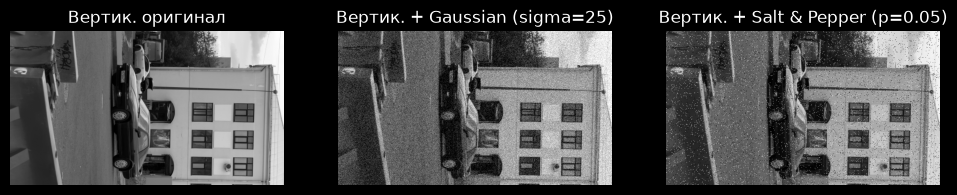

In [13]:
def show_images(images, titles, cmap="gray", fig_h=5):
    """Изображения выводятся в одну строку (по горизонтали)."""
    n = len(images)
    fig, ax = plt.subplots(1, n, figsize=(4 * n, fig_h))
    for i, a in enumerate(ax):
        a.imshow(images[i], cmap=cmap)
        a.set_title(titles[i])
        a.axis("off")
    plt.show()


portrait = cv2.rotate(gray, cv2.ROTATE_90_CLOCKWISE)
portrait_gauss = add_gaussian(portrait, sigma=25)
portrait_sp = add_salt_pepper(portrait, p=0.05)
show_images([portrait, portrait_gauss, portrait_sp],
            ["Вертик. оригинал",
             "Вертик. + Gaussian (sigma=25)",
             "Вертик. + Salt & Pepper (p=0.05)"])


### (Доп) Свой шум «соль и перец» — какой фильтр справляется лучше всех---

In [14]:
for p in [0.02, 0.05, 0.1]:
    sp = add_salt_pepper(gray, p)
    print(f"--- p = {p}: PSNR фильтров vs оригинал ---")
    for fname, f in [("Усредняющий", lambda im: cv2.blur(im, (5, 5))),
                     ("Гауссовский", lambda im: cv2.GaussianBlur(im, (5, 5), 0)),
                     ("Медианный", lambda im: cv2.medianBlur(im, 3))]:
        print(f"  {fname:12s}: {psnr(gray, f(sp)):.2f} дБ")
    print()


--- p = 0.02: PSNR фильтров vs оригинал ---
  Усредняющий : 26.08 дБ
  Гауссовский : 28.08 дБ
  Медианный   : 31.74 дБ

--- p = 0.05: PSNR фильтров vs оригинал ---
  Усредняющий : 25.18 дБ
  Гауссовский : 26.12 дБ
  Медианный   : 31.36 дБ

--- p = 0.1: PSNR фильтров vs оригинал ---
  Усредняющий : 23.84 дБ
  Гауссовский : 23.90 дБ
  Медианный   : 30.54 дБ



### (Доп) Подбор порогов Canny


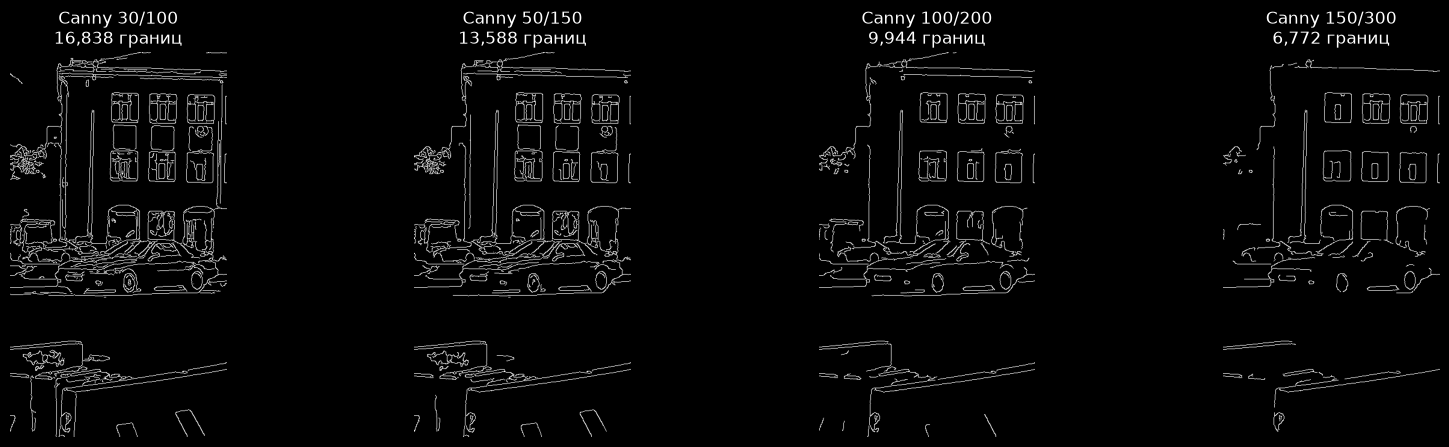

  30/100 -> 16,838 граничных пикселей
  50/150 -> 13,588 граничных пикселей
  100/200 -> 9,944 граничных пикселей
  150/300 -> 6,772 граничных пикселей


In [15]:
med = cv2.medianBlur(noisy_sp, 5)
thresholds = [(30, 100), (50, 150), (100, 200), (150, 300)]

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a, (lo, hi) in zip(ax, thresholds):
    e = cv2.Canny(med, lo, hi)
    a.imshow(e, cmap="gray")
    a.set_title(f"Canny {lo}/{hi}\n{np.count_nonzero(e):,} границ")
    a.axis("off")
plt.show()

for lo, hi in thresholds:
    print(f"  {lo}/{hi} -> {np.count_nonzero(cv2.Canny(med, lo, hi)):,} граничных пикселей")
